In [78]:
import pandas as pd
import numpy as np 
import time 
import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots



sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100
RANDOM_STATE = 42

# 1. Load & Visualize 

### 1.1 Import Data from sklearn

In [79]:
from sklearn.datasets import load_digits

digits = load_digits()
X,y = digits.data, digits.target

print("                --- Data Set Info ---       ")
print(f"Data Shape : {X.shape} | Images(gray): {X.shape[0]} | Pixels : {X.shape[1]}")
print(f"Classes : {np.unique(y)} | Class count : {len(np.unique(y))}")
print(f"Pixel Value range : {X.min()} to {X.max()}")


                --- Data Set Info ---       
Data Shape : (1797, 64) | Images(gray): 1797 | Pixels : 64
Classes : [0 1 2 3 4 5 6 7 8 9] | Class count : 10
Pixel Value range : 0.0 to 16.0


### 1.2 Visualize Digits 

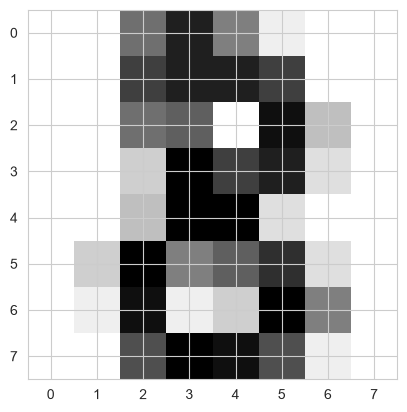

In [ ]:
# Digit to check
d = 8

# Find Index of digit
idx = np.where(y==d)[0][0]

# Image is in vector for (64,) need to convert into 2D array(8X8) format
plt.imshow(X[idx].reshape(8,8), cmap='gray_r')
plt.show()

### 1.3 Visualize all Digits 

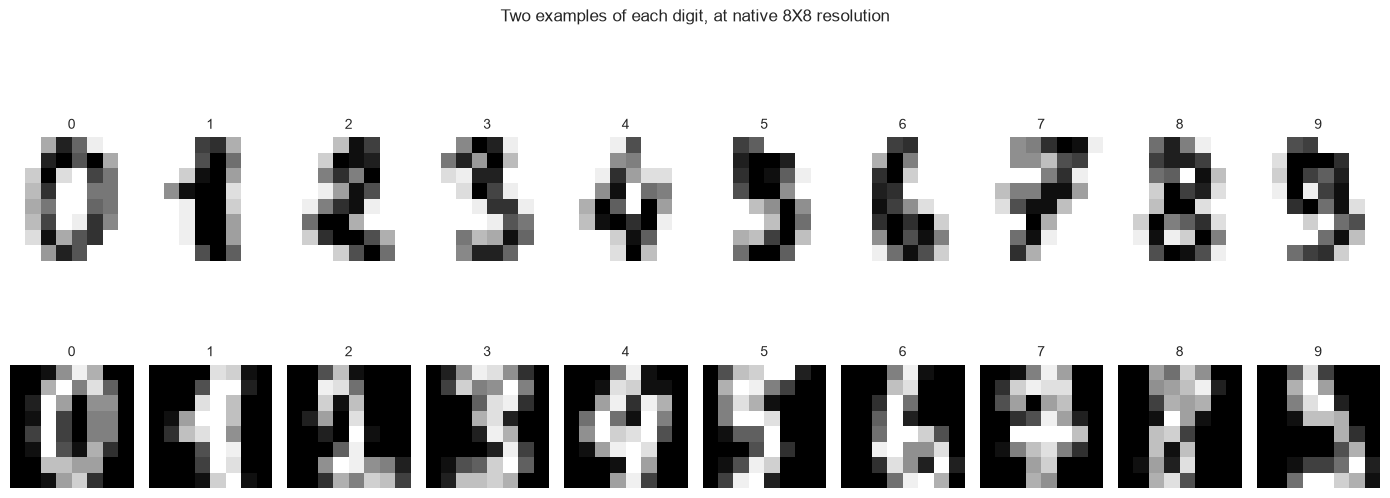

In [81]:
fig, axes = plt.subplots(2,10, figsize=(14, 6))

# Total Digit Count
total_digit = len(np.unique(y))

# Print All the Digits
for digit in range(total_digit):
    
    idx = np.where(y==digit)[0][0]
    axes[0, digit].imshow(X[idx].reshape(8,8), cmap='gray_r')
    axes[0, digit].set_title(str(digit), fontsize=10)
    axes[0,digit].axis('off')
    
    idx2 = np.where(y == digit)[0][1]
    axes[1, digit].imshow(X[idx2].reshape(8,8), cmap='gray')
    axes[1, digit].set_title(str(digit), fontsize=10)
    axes[1,digit].axis('off')

plt.suptitle("Two examples of each digit, at native 8X8 resolution")
plt.tight_layout()
plt.show()


**Observation:** 

1. At 8x8 resolution these are genuinely blurry — real MNIST's 28x28 gives much crisper digits. That resolution difference is
   exactly why this notebook's absolute numbers won't match a full-MNIST run. 
2. the *method* for deciding on PCA still transfers unchanged.

# 2. Baseline KNN Model (raw pixels)

Standardizing pixel values first (mean = 0, variance = 1) matters here for two separate reasons: 

1. KNN is distance-based, so unscaled features with larger raw ranges would dominate the distance calculation.

2. PCA later in this notebook is defined in terms of variance, so it needs to operate on a comparable scale across pixels too. Splitting before scaling avoids leaking test-set statistics into the transform.

### 2.1 Feature Scaling

In [82]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# Split data into training and testing sets
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=RANDOM_STATE)

# scaling the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

print(f"Train Data : {X_train_scaled.shape}")
print(f"Test Data  : {X_test_scaled.shape}")

Train Data : (1437, 64)
Test Data  : (360, 64)


### 2.2 Model (KNN)

In [83]:
def knn_benchmark(X_train, X_test_small, X_test_large, y_train, y_test, n_neighbors=5, timing_repeats=7):
    
    # KNN Classifier
    knn_clf = KNeighborsClassifier(n_neighbors=n_neighbors, algorithm='brute')
    
    # Train the model on the training data
    start_time = time.perf_counter()
    knn_clf.fit(X_train, y_train)
    train_time = time.perf_counter() - start_time
    
    
    # Predict on the test data
    y_pred = knn_clf.predict(X_test_small)
    accuracy_small = accuracy_score(y_test, y_pred)
    
    # Predict on the test data for the large dataset
    times = []
    for _ in range(timing_repeats):
        start_time = time.perf_counter()
        knn_clf.predict(X_test_large)
        times.append(time.perf_counter() - start_time)
    
    # Calculate the average training time for 1000 predicts
    pred_per_1000 = (np.mean(times) / len(X_test_large)) * 1000 * 1000
    
    return {"accuracy":accuracy_small, "train_time_s":train_time, "pred_per_1000":pred_per_1000}


### 2.3 Baseline Model Evaluation

In [84]:
# Making Large DataSet 
TILES = 60
X_test_tiled = np.tile(X_train,(TILES,1))

# Model training and evaluation
baseline_model = knn_benchmark(X_train_scaled, X_test_scaled, X_test_tiled, y_train, y_test)

print(f"------ Baseline Model -----")
print(f" Accuracy         : {baseline_model['accuracy']:3f}")
print(f" Training Time    : {baseline_model['train_time_s']*1000:.3f} ms")
print(f" Prediction speed : {baseline_model['pred_per_1000']:.2f} ms per 1,000 predictions")

------ Baseline Model -----
 Accuracy         : 0.969444
 Training Time    : 1.900 ms
 Prediction speed : 0.94 ms per 1,000 predictions


**Why the prediction timing is done this way:** 

- With only ~450 test images, timing a single `.predict()` call is dominated by Python-level call overhead, not the actual distance computation the dimensionality comparison cares about. 

- Tiling the test set to a much larger batch and timing that instead isolates the effect  that's what actually we wants to measure. 

- `algorithm="brute"` is also set explicitly scikit-learn's default KNN auto-picks between tree-based and brute-force search depending on dimensionality, which would confound a "how does prediction cost change with dimension" comparison with "which internal algorithm did sklearn happen to choose." Brute-force distance computation cost scales directly with the number of features, which is exactly the relationship being tested here.

# 3. Principal Component Analysis (PCA)



### 3.1 Fit PCA  (Examine Explained Variance)
Fit PCA on the *training* data only to avoid leaking information from the test set into the training process. 

In [85]:
from sklearn.decomposition import PCA

# Transform X_train_scaled to get the principal components. 
X_pca = PCA(random_state=RANDOM_STATE).fit(X_train_scaled)

# Explained variance ratio of the principal components. 
explained_var = X_pca.explained_variance_ratio_

# Variance Explained by each principal component. 
cumulative_var = np.cumsum(explained_var)

# Variance DataFrame
variance_df = pd.DataFrame({
    "Components": np.arange(1, len(explained_var)+1),
    "Explained variance": explained_var,
    "Cumulative variance": cumulative_var
})

variance_df.head(10)

,Components,Explained variance,Cumulative variance
0,1,0.120380,0.120380
1,2,0.097331,0.217711
2,3,0.085618,0.303329
3,4,0.064938,0.368267
4,5,0.048879,0.417146
5,6,0.042640,0.459787
6,7,0.039494,0.499280
7,8,0.033496,0.532777
8,9,0.030236,0.563012
9,10,0.029319,0.592332


### 3.2 Examine Explained and cumulative Variance 


In [86]:
fig = make_subplots(specs=[[{"secondary_y": True}]])

# For Explained Variance
fig.add_trace(go.Bar(
    x=variance_df["Components"], y=variance_df["Explained variance"],
    name="Explained Variance (per component)", marker_color="#2980b9",opacity=0.7
), secondary_y=False)

# For Cumulative Explained Variance
fig.add_trace(go.Scatter(
    x=variance_df["Components"], y=variance_df["Cumulative variance"],
    name="Cumulative Explained Variance",line=dict(color="#c0392b", width=2), marker=dict(size=4)
    ), secondary_y=True)

# Add horizontal lines at 90%, 95%, and 99%
for pct in [0.90, 0.95, 0.99]:
    fig.add_hline(y=pct, line_dash="dash", line_color="gray",
                annotation_text=f"{int(pct*100)}%", secondary_y=True)

# Add title and annotations
fig.update_layout(title="Screen plot + Cumulative Explained Variance",
                xaxis_title='Principal component', height=400,
                hovermode="x unified", legend=dict(x=0.7, y=0.3))

# Update y-axis titles and range for secondary axes
fig.update_yaxes(title_text="Explained var(per component)", secondary_y=False)
fig.update_yaxes(title_text="Cumulative Evar", secondary_y=True, range=[0, 1.02])
fig.show()


**Observation:** 

- The bars (individual variance per component) drop off steeply after the first handful of components — classic scree-plot shape.

- The cumulative line answers a different, more useful question: how many components are needed to keep a given *fraction* of the original
information. Both views matter

- The bars show *where* the elbow is, the cumulative line shows *what it costs* to stop there.

# 4. Component analysis: how many components are needed?

### 4.1 Deciding the number of components — three criteria, compared

Picking a number "by eye" from the plot above is a real method (the
**elbow method** — find where the curve visibly flattens), but it's worth
comparing against two more formal criteria before trusting it.


In [87]:
# percentage of variance explained 
thresholds = [0.80, 0.90, 0.95, 0.99]

# Component Need for Thresholds
components_threshold = {}


# Find Components that explain at least threshold percentage of variance
for i in thresholds:
    k = int(np.argmax(cumulative_var >= i) + 1)
    components_threshold[i] = k
    print(f"Components need for {int(i*100)}% CV : {k}")

# Kaiser criterion (components with eigenvalue > 1)
kaiser_k = int(np.sum(X_pca.explained_variance_ > 1.0))


print(f"\nKaiser criterion (components with eigenvalue > 1): {kaiser_k}\n")

note = str(f"Note: Eigenvalue here  = explained_variance_ , not the ratio."
f"\n      A component with eigenvalue > 1 explains more variance then a single original,\n      standardized feature would on its own.")
print(note)

Components need for 80% CV : 21
Components need for 90% CV : 31
Components need for 95% CV : 40
Components need for 99% CV : 54

Kaiser criterion (components with eigenvalue > 1): 17

Note: Eigenvalue here  = explained_variance_ , not the ratio.
      A component with eigenvalue > 1 explains more variance then a single original,
      standardized feature would on its own.


### 4.2 Plot component selection 

In [ ]:
fig = go.Figure()

# For Cumulative Variance
fig.add_trace(go.Scatter(
    x=variance_df["Components"], y=variance_df["Cumulative variance"],
    mode="lines+markers",name="Cumulative Variance",
    line=dict(color="#2980b9")
))

# Percentage of Variance and color
colors = {"80%": "#95a5a6", "90%": "#f39c12", "95%": "#e67e22", "99%": "#c0392b"}
k_list = {0.80: "80%", 0.90:"90%",0.95:"95%",0.99:"99%"}


# Add vertical lines for stopping criteria for given thresholds
for t in k_list:
    k = components_threshold[t]
    fig.add_vline(x=k, line_dash="dot", line_color=colors[k_list[t]],
                annotation_text=f"{k_list[t]}: k={k}", annotation_position="top")

# Add vertical line for kaiser criterion
fig.add_vline(x=kaiser_k, line_dash="dash", line_color="#8e44ad",
            annotation_text=f"k'={kaiser_k}", annotation_position="bottom")

# Update layout
fig.update_layout(title="Stopping Criterion (k' : kaiser criterion)", xaxis_title="Number of Components",
                yaxis_title="Cumulative explained variance", height=400)
fig.show()

**Observation:** 

- These criteria don't agree with each other — Kaiser's criterion (17 components) lands modestly to the left of even the 80%
variance mark (21), while the 95% and 99% marks sit much further right (40 and 54).

- The Kaiser criterion is a bit more conservative than the other two. It's not clear why this might be, or why it's not more aggressive. 
for this task, which turns out to be 30 — below the 95%/99% thresholds but above every other rule of thumb shown here.

- That's exactly why Section 7 picks the number **empirically, from downstream task performance, rather than from any single one of these statistical rules of thumb.** All three are useful starting points; none of them knows what the KNN classifier actually needs. 

# 5. Visualizing the digits in PCA space

Project onto just the first 2 and first 3 components — far too few to
classify well (confirmed numerically in Section 7), but exactly the
number needed to actually look at the data.

### 5.1 PCA with 2 Components

In [ ]:
# Extracting Two Components from the PCA model
pca_2d = PCA(n_components=2, random_state=RANDOM_STATE).fit(X_train_scaled)
X_train_2d = pca_2d.transform(X_train_scaled)

# Creating a DataFrame with the transformed data and target labels
df_2d = pd.DataFrame(X_train_2d, columns=['PC1', 'PC2'])
df_2d['Target'] = y_train.astype(str)

# Sorting Target values in ascending order to ensure correct ordering on the plot
df_2d = (
    df_2d.sort_values("Target", key=lambda col: col.astype(int)).reset_index(drop=True)
)

print(" ---- PCA with 2 Components ----")
df_2d

 ---- PCA with 2 Components ----


,PC1,PC2,Target
0,-2.121604,-2.508564,0
1,-3.060117,-1.633486,0
2,-1.512606,-2.514647,0
3,-1.733271,-3.282316,0
4,-0.748772,-1.802150,0
...,...,...,...
1432,1.513990,-1.442449,9
1433,1.888960,1.569353,9
1434,2.213477,-0.952252,9
1435,1.246415,-0.620782,9


In [88]:
#  plot the data points on a scatter plot with color-coded labels.
fig = px.scatter(df_2d, x='PC1', y='PC2', color='Target',
                title="Projected Data onto PCA Components",
                color_discrete_sequence=px.colors.qualitative.Bold,
                opacity=0.7, height=550)


fig.update_traces(marker=dict(size=7))

fig.show()

**Observation:** 

- Some digits (commonly 0 and 6, or 4 and 9-adjacent clusters, depending on the random split) separate reasonably well in just 2 dimensions others overlap heavily. 

- That overlap is the direct visual explanation for why 2 components alone give poor KNN accuracy — the classes genuinely aren't separable in a space this small, no matter how good the classifier is.

### 5.2 PCA with 3 components

In [74]:
# Extracting 3 components from the PCA model
pca_3d = PCA(n_components=3, random_state=RANDOM_STATE).fit(X_train_scaled)
X_train_3d = pca_3d.transform(X_train_scaled)

# Creating a DataFrame with the transformed data and target labels
df_3d = pd.DataFrame(X_train_3d, columns=['PC1', 'PC2', 'PC3'])
df_3d['Target'] = y_train.astype(str)

# sorting the DataFrame by target label to ensure they are in order before plotting
df_3d = (
    df_3d.sort_values("Target", key=lambda col: col.astype(int)).reset_index(drop=True)
)

print("    ---- PCA with 3 Components ---")
df_3d

    ---- PCA with 3 Components ---


,PC1,PC2,PC3,Target
0,-2.121604,-2.508564,-2.747276,0
1,-3.060117,-1.633486,-2.596415,0
2,-1.512606,-2.514647,-2.375699,0
3,-1.733271,-3.282316,-1.599940,0
4,-0.748772,-1.802150,-4.609984,0
...,...,...,...,...
1432,1.513990,-1.442449,-2.658267,9
1433,1.888960,1.569353,-1.390920,9
1434,2.213477,-0.952252,-3.822874,9
1435,1.246415,-0.620782,-2.791473,9


In [75]:
fig = px.scatter_3d(df_3d, x='PC1', y='PC2',z='PC3', color='Target',
                title="Projected Data onto PCA Components",
                color_discrete_sequence=px.colors.qualitative.Bold,
                opacity=0.6, height=700)

fig.update_traces(marker=dict(size=4))

fig.show()

**Observation:** 
The third dimension visibly pulls apart some of the clusters that overlapped in the 2D view  a direct, visual demonstration
of *why* more components generally help.

# 6. Image reconstruction (what's actually being kept vs. discarded)

PCA is reversible: project down to k components, then project back up to the original 64 dimensions, and compare the result to the original image.The gap between them is exactly the information that choice of k throw away.

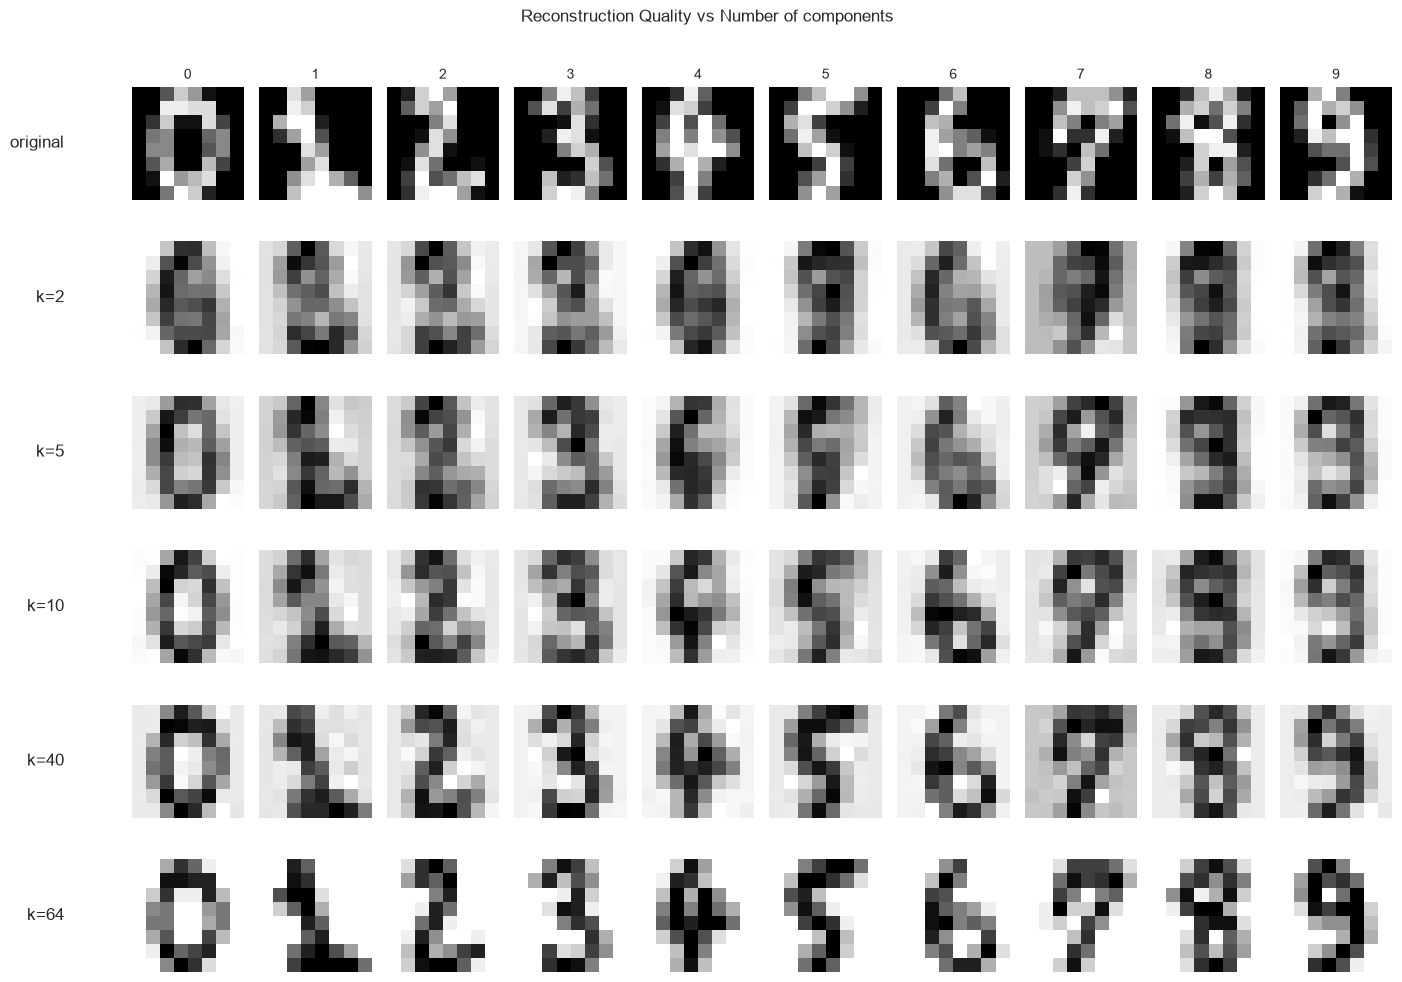

In [76]:
# Image samples 
sample_idx = [np.where(y_test == d)[0][0] for d in range(total_digit)]
sample_images = X_test_scaled[sample_idx]


# Component counts 
component_count = [2, 5, 10, 40, 64]


fig, axes = plt.subplots(len(component_count)+1, 10 ,figsize=(14, 10))

# Base image reconstruction
for col in range(total_digit):
    original = scaler.inverse_transform(sample_images[col].reshape(1, -1))
    axes[0, col].set_title(str(col), fontsize=10)
    axes[0, col].imshow(original.reshape(8,8), cmap="gray")
    axes[0, col].axis("off")
    if col == 0:
        axes[0, col].set_ylabel("Original", fontsize=9, rotation=0, labelpad=40)
        


# PCA reconstruction with different number of components
for row, k in enumerate(component_count, start=1):
    
    pca_k = PCA(n_components=k, random_state=RANDOM_STATE).fit(X_train_scaled)
    projected = pca_k.transform(sample_images)
    reconstructed_scaled = pca_k.inverse_transform(projected)
    reconstructed = scaler.inverse_transform(reconstructed_scaled)
    
    for col in range(10):
        axes[row, col].imshow(reconstructed[col].reshape(8,8), cmap="gray_r")
        axes[row, col].axis("off")


# label each subplot on top of each subplot
for row, label in enumerate(["original"] + [f"k={k}" for k in component_count]):
    axes[row, 0].text(-0.6, 0.5, label, fontsize=12, ha='right', va='center',
                    transform=axes[row, 0].transAxes)


plt.suptitle("Reconstruction Quality vs Number of components", y=1.0)
plt.tight_layout()
plt.show()


**Observation:**

- At k=2 the digits are barely recognizable blobs by k=20 most are legible by k=40 the reconstruction is close to
indistinguishable from the original by eye.

- This is the same story the variance plot told numerically (k=40 lines up with the 95% variance mark
from sub-Section 4.2) — reconstruction quality is the direct visual meaning behind "percentage of variance explained."

## 7. KNN on PCA-reduced data 

Sweep across a range of component counts (rather than picking just one) so the trade-off is visible as a curve, not a single before/after
snapshot.

### 7.1 Model Evaluation on k component PCA data

In [89]:
# custom component range
component_range = [2, 5, 10, 15, 20, 30, 40, 54, 64]
sweep_results = []

for k in component_range:
    pca_k =  PCA(n_components=k, random_state=RANDOM_STATE).fit(X_train_scaled)
    X_train_k = pca_k.transform(X_train_scaled)
    X_test_k = pca_k.transform(X_test_scaled)
    X_test_k_tiled = np.tile(X_test_k, (TILES, 1))
    
    # Model Evaluation on k component PCA data
    result = knn_benchmark(X_train_k, X_test_k, X_test_k_tiled, y_train, y_test)
    
    # Cache Model Evaluation results
    sweep_results.append({
        "n_components": k,
        "Cumulative Variance": cumulative_var[k-1],
        "accuracy": result["accuracy"],
        "speed_per_1000": result["pred_per_1000"],
    })

# Convert results to DataFrame
sweep_df = pd.DataFrame(sweep_results)
sweep_df.round(4)

,n_components,Cumulative Variance,accuracy,speed_per_1000
0,2,0.2177,0.5444,0.5597
1,5,0.4171,0.8778,0.4804
2,10,0.5923,0.9278,0.5222
3,15,0.7126,0.9583,0.5856
4,20,0.7960,0.9611,0.5877
5,30,0.8956,0.9639,0.6618
6,40,0.9518,0.9639,0.8459
7,54,0.9911,0.9694,0.9828
8,64,1.0000,0.9694,1.0592


### 7.2 Prediction Accuracy and Speed with the k Component PCA

In [90]:
fig = make_subplots(specs=[[{"secondary_y": True}]])


# For Accuracy
fig.add_trace(go.Scatter(x=sweep_df["n_components"], y=sweep_df["accuracy"],
                        mode="lines+markers", name="Accuracy",
                        line=dict(color="#2980b9", width=2)), secondary_y=False)

# For Speed
fig.add_trace(go.Scatter(x=sweep_df["n_components"], y=sweep_df["speed_per_1000"],
                        mode="lines+markers", name="Prediction time (ms/ per 1000)",
                        line=dict(color="#c0392b", width=2)), secondary_y=True)

# Add baseline line
fig.add_hline(y=baseline_model["accuracy"], line_dash="dash", line_color="#7f8c8d",
            annotation_text="Baseline accuracy(64 rows)", secondary_y=False)

# Add legend
fig.update_layout(title="Accuracy vs Prediction time for different number of components",
                xaxis_title="Number of components",height=500, hovermode='x unified')

fig.update_yaxes(title_text="Accuracy", secondary_y=False)
fig.update_yaxes(title_text="Prediction time (ms/ per 1000)", secondary_y=True)

**Observation:** 

- Accuracy climbs steeply up to about 10-15 components, then flattens — by 30 components it's statistically indistinguishable from the 64-dimension baseline, matching what Section 6's reconstructions showed visually. 

- Prediction time tracks dimensionality fairly directly once `algorithm="brute"` removes sklearn's internal algorithm-switching as a confound, exactly as expected from the theoretical cost of a brute-force distance calculation scaling with feature count.

### 7.3 Model Comparison raw pixels vs PCA-reduced pixel

In [91]:

# From the analysis of the PCA-reduced pixel data, we can see that the k=30 component model is the most accurate and fastest. 
best_reduced = sweep_df[sweep_df["n_components"] == 30].iloc[0]

# DataFrame of Baseline Model and PCA-reduced Model
comparison = pd.DataFrame({
    "Baseline (64 raw pixels)":[
        baseline_model["accuracy"],1.0,
        baseline_model["pred_per_1000"]
    ],
    "PCA-reduced (30 Components)":[
        best_reduced["accuracy"],
        best_reduced["Cumulative Variance"],
        best_reduced["speed_per_1000"]
    ]
}, index=["Accuracy","Cumulative Variance","Speed per 1000(ms)"])

# Comparison Table
comparison["Delta"] = [
    f"{(comparison.iloc[0,1] - comparison.iloc[0,0]):+.4f}",
    f"{(comparison.iloc[1,1] - comparison.iloc[1,0]):+.4f}",
    f"{((comparison.iloc[2,1] /  comparison.iloc[2,0])-1)*100:+1f}%"
]
comparison

,Baseline (64 raw pixels),PCA-reduced (30 Components),Delta
Accuracy,0.969444,0.963889,-0.0056
Cumulative Variance,1.000000,0.895618,-0.1044
Speed per 1000(ms),0.942533,0.661831,-29.781626%


**Conclusion:** 

- 30 components — well short of the 95% variance mark (which needed 40) and nowhere near the full 64 — retains effectively all
the classification accuracy while cutting prediction time by roughly a
quarter. 

- This is the practical answer to Section 4's disagreement between criteria: **validate against the actual downstream task.** The variance threshold, the elbow, and Kaiser's criterion are all useful starting points to narrow the search; the number that actually matters is the one where task performance stops improving.

## 8. Confusion matrices — baseline vs. PCA-reduced (30 components)

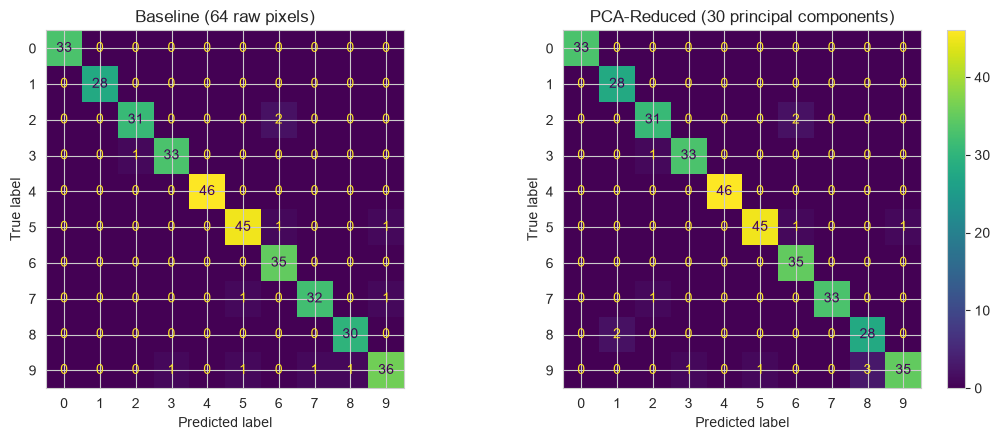

In [22]:
pca_30 = PCA(n_components=30, random_state=RANDOM_STATE).fit(X_train_scaled)
X_train_pca_30 = pca_30.transform(X_train_scaled)
X_test_pca_30 = pca_30.transform(X_test_scaled)

knn_baseline = KNeighborsClassifier(n_neighbors=5,algorithm="brute").fit(X_train_scaled, y_train)
knn_pca_30 = KNeighborsClassifier(n_neighbors=5,algorithm="brute").fit(X_train_pca_30, y_train)

fig, axes = plt.subplots(1, 2, figsize=(11,4.5))

ConfusionMatrixDisplay.from_estimator(knn_baseline, X_test_scaled, y_test,ax=axes[0],colorbar=False)
axes[0].set_title("Baseline (64 raw pixels)")

ConfusionMatrixDisplay.from_estimator(knn_pca_30, X_test_pca_30, y_test,ax=axes[1], colorbar=True)
axes[1].set_title("PCA-Reduced (30 principal components)")
plt.tight_layout()
plt.show()


**Observation:** the two confusion matrices are near-identical — the same handful of visually-similar digit pairs (commonly around 3/8/9 or
4/9-style confusions, dataset-dependent) account for most of the errors in *both* versions. PCA to 30 components didn't introduce new confusions or resolve existing ones; it just achieved the same error pattern more cheaply.

---
## 9. General insights and caveats

**1. PCA's speed benefit is largest for distance-based models on
genuinely high-dimensional data.** KNN computes a distance for every
feature on every comparison, so cutting dimensionality directly cuts that
cost — the mechanism demonstrated in Section 7. This effect scales with
both the original dimensionality and the dataset size; on real 784-pixel
MNIST (or higher-resolution image data) the absolute time saved would be
far larger than what a 64-pixel toy dataset can show, even though the
relative pattern is identical. It also matters far less for models that
don't compute pairwise distances (e.g. a single decision tree barely
cares how many irrelevant dimensions exist).

**2. No single "pick k" rule is reliable on its own.** Section 4 showed
three formal criteria disagreeing with each other by a wide margin on the
same data. All of them are reasonable *starting points* for narrowing a
search range; none of them replace actually checking downstream task
performance, which is the only criterion that answers the question that
actually matters ("does my model still work").

**3. Reconstruction quality is the concrete, visual meaning of "percentage
of variance explained."** It's easy to treat explained-variance numbers as
abstract; Section 6 ties a specific number (95% variance, k=40) to a
specific, visible amount of image quality lost. That translation is worth
doing whenever PCA's output feeds into a further decision, not just for
images — the same logic applies to reconstructing tabular rows, even
though there's nothing to look at directly.

**4. Standardizing before PCA is not optional when features are on
different scales.** This dataset's pixels are already on a shared 0-16
scale, so scaling mattered less here than it would on genuinely
heterogeneous tabular features (recall the Filter Methods series'
Variance Threshold notebook, where raw sensor variances spanned many
orders of magnitude) — but the discipline of splitting before scaling,
and scaling before PCA, generalizes regardless of whether this particular
dataset would have tolerated skipping it.

**5. PCA changes *what* the model sees, not *whether* it can separate the
classes.** The confusion matrix comparison in Section 8 is the important
check here: if PCA had introduced new error patterns not present in the
baseline, that would signal information loss that actually mattered for
this task. It didn't — the errors PCA has are the errors the raw pixels
already had, just reached more cheaply.
